In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# Reload data
df = pd.read_csv('../data/master/eda_output.csv')
df_model = df.dropna(subset=['log_new_business_density']).copy()

features_final = ['governance_index', 'log_gdp_per_capita', 'internet_users', 'unemployment_rate']
df_model = df_model.dropna(subset=features_final)

X = df_model[features_final].copy()
y = df_model['log_new_business_density']

# Same country-based split
countries = df_model['country_code'].unique()
train_countries, test_countries = train_test_split(countries, test_size=0.2, random_state=42)
train_mask = df_model['country_code'].isin(train_countries)
test_mask = df_model['country_code'].isin(test_countries)

X_train_f, X_test_f = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

# Refit final model
lr_final = LinearRegression()
lr_final.fit(X_train_f, y_train)

# Standardized version for SHAP
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train_f)
X_test_scaled = scaler_X.transform(X_test_f)

lr_std = LinearRegression()
lr_std.fit(X_train_scaled, y_train)

print("Rebuild complete.")
print(f"Test R²: {r2_score(y_test, lr_std.predict(X_test_scaled)):.4f}")

C:\Users\AJAY\AppData\Roaming\Python\Python310\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Rebuild complete.
Test R²: 0.3950


In [2]:
# Setup + SHAP explainer

import shap

# For Linear Regression, SHAP's LinearExplainer is exact and fast (no approximation needed)
explainer = shap.LinearExplainer(lr_std, X_train_scaled, feature_names=features_final)
shap_values = explainer(X_test_scaled)

print("SHAP values shape:", shap_values.values.shape)

SHAP values shape: (507, 4)


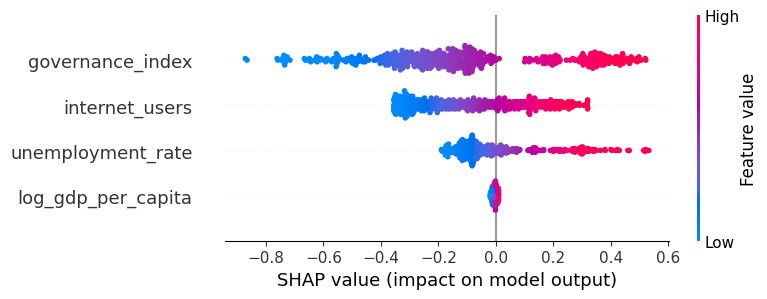

In [3]:
shap.summary_plot(shap_values, X_test_scaled, feature_names=features_final)

In [4]:
mean_abs_shap = pd.DataFrame({
    'feature': features_final,
    'mean_abs_shap': np.abs(shap_values.values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)
print(mean_abs_shap)

              feature  mean_abs_shap
0    governance_index       0.283979
2      internet_users       0.185761
3   unemployment_rate       0.122114
1  log_gdp_per_capita       0.006118


In [5]:
# Sanity check the direction of unemployment_rate's relationship
print(df_model[['unemployment_rate', 'log_new_business_density']].corr())

                          unemployment_rate  log_new_business_density
unemployment_rate                  1.000000                  0.173156
log_new_business_density           0.173156                  1.000000


## SHAP Explainability Findings

- **governance_index**: strongest and most consistent driver — high governance → strongly positive 
  SHAP contribution, low governance → strongly negative. Matches standardized coefficient ranking.
- **internet_users**: second most influential, similar clean directional relationship.
- **unemployment_rate**: positive relationship with target (r=0.17, confirmed via both raw 
  correlation and SHAP direction) — counterintuitive at first glance, but consistent with the 
  "necessity entrepreneurship" concept in development economics (people start businesses when 
  formal jobs are scarce). A modest, secondary effect, not a dominant driver.
- **log_gdp_per_capita**: SHAP contributions compressed near zero — confirms multicollinearity 
  finding (VIF=9.56); GDP's effect is largely absorbed by governance_index and internet_users.

**Consistency check**: SHAP mean |value| ranking (governance > internet > unemployment > GDP) 
matches the standardized coefficient ranking exactly — two independent explainability methods 
agree, reinforcing confidence in the interpretation.

Country: Burundi, Year: 2012
Actual log density: 0.231, Predicted: 0.021


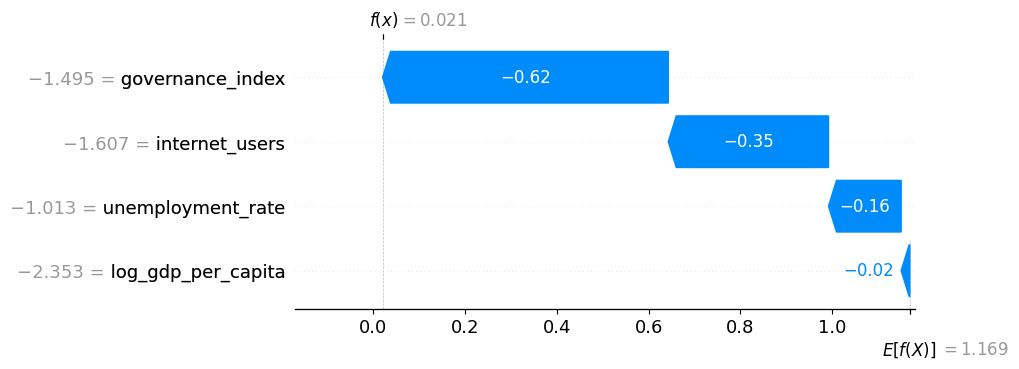

In [6]:
# Pick a test-set country to explain, e.g. the first row
idx = 0
country_row = df_model[test_mask].iloc[idx]
print(f"Country: {country_row['country_name']}, Year: {country_row['year']}")
print(f"Actual log density: {y_test.iloc[idx]:.3f}, Predicted: {lr_std.predict(X_test_scaled[idx:idx+1])[0]:.3f}")

shap.plots.waterfall(shap_values[idx])

In [7]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train_f)
X_test_sm = sm.add_constant(X_test_f)

ols_model = sm.OLS(y_train, X_train_sm).fit()
pred = ols_model.get_prediction(X_test_sm)
pred_summary = pred.summary_frame(alpha=0.05)  # 95% interval

print(pred_summary.head())

         mean   mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
196  0.020924  0.034622      -0.046973       0.088821     -1.052460   
197  0.055247  0.034980      -0.013352       0.123845     -1.018182   
198  0.119706  0.035423       0.050240       0.189173     -0.953778   
199  0.021450  0.033651      -0.044544       0.087443     -1.051815   
200 -0.019789  0.034283      -0.087021       0.047443     -1.093131   

     obs_ci_upper  
196      1.094308  
197      1.128675  
198      1.193191  
199      1.094715  
200      1.053553  


In [8]:
import os
os.makedirs('../models', exist_ok=True)

In [9]:
import joblib

# Save the trained model + scaler
joblib.dump(lr_final, '../models/final_linear_model.pkl')
joblib.dump(scaler_X, '../models/feature_scaler.pkl')

# Build the final prediction dataset: actual, predicted, intervals, SHAP contributions, metadata
output_df = df_model[test_mask][['country_code', 'country_name', 'year', 'region', 'income_group', 
                                    'is_offshore_center', 'new_business_density']].copy()
output_df['log_actual'] = y_test.values
output_df['log_predicted'] = lr_final.predict(X_test_f)
output_df['pred_ci_lower'] = pred_summary['obs_ci_lower'].values
output_df['pred_ci_upper'] = pred_summary['obs_ci_upper'].values

for i, feat in enumerate(features_final):
    output_df[f'shap_{feat}'] = shap_values.values[:, i]

output_df.to_csv('../data/master/dashboard_predictions.csv', index=False)
print(output_df.shape)
output_df.head()

(507, 15)


,country_code,country_name,year,region,income_group,is_offshore_center,new_business_density,log_actual,log_predicted,pred_ci_lower,pred_ci_upper,shap_governance_index,shap_log_gdp_per_capita,shap_internet_users,shap_unemployment_rate
196,BDI,Burundi,2012,Sub-Saharan Africa,Low income,False,0.260444,0.231464,0.020924,-1.052460,1.094308,-0.621848,-0.018849,-0.348837,-0.158152
197,BDI,Burundi,2013,Sub-Saharan Africa,Low income,False,0.378827,0.321233,0.055247,-1.018182,1.128675,-0.587674,-0.018764,-0.348538,-0.158387
198,BDI,Burundi,2014,Sub-Saharan Africa,Low income,False,0.393577,0.331874,0.119706,-0.953778,1.193191,-0.521743,-0.018421,-0.350039,-0.158701
199,BDI,Burundi,2015,Sub-Saharan Africa,Low income,False,0.272804,0.241222,0.021450,-1.051815,1.094715,-0.623344,-0.018340,-0.343561,-0.161916
200,BDI,Burundi,2016,Sub-Saharan Africa,Low income,False,0.386564,0.326829,-0.019789,-1.093131,1.053553,-0.662933,-0.018807,-0.342208,-0.164452


In [11]:
# X, y here should already be the full 2618-row modeling set from earlier in this notebook
X_full_scaled = scaler_X.transform(X)
y_pred_full = lr_final.predict(X)

shap_values_full = explainer(X_full_scaled)

X_full_sm = sm.add_constant(X)
pred_full = ols_model.get_prediction(X_full_sm)
pred_summary_full = pred_full.summary_frame(alpha=0.05)

output_full = df_model[['country_code', 'country_name', 'year', 'region', 'income_group', 
                          'is_offshore_center', 'new_business_density']].copy()
output_full['log_actual'] = y.values
output_full['log_predicted'] = y_pred_full
output_full['pred_ci_lower'] = pred_summary_full['obs_ci_lower'].values
output_full['pred_ci_upper'] = pred_summary_full['obs_ci_upper'].values
output_full['split'] = np.where(output_full['country_code'].isin(test_countries), 'test', 'train')

for i, feat in enumerate(features_final):
    output_full[f'shap_{feat}'] = shap_values_full.values[:, i]

output_full.to_csv('../data/master/dashboard_predictions_full.csv', index=False)
print(output_full.shape)
print(output_full['split'].value_counts())
output_full.head()

(2618, 16)
split
train    2111
test      507
Name: count, dtype: int64


,country_code,country_name,year,region,income_group,is_offshore_center,new_business_density,log_actual,log_predicted,pred_ci_lower,pred_ci_upper,split,shap_governance_index,shap_log_gdp_per_capita,shap_internet_users,shap_unemployment_rate
3,AFG,Afghanistan,2009,"Middle East, North Africa, Afghanistan & Pakistan",Low income,False,0.272384,0.240892,0.006823,-1.065709,1.079355,train,-0.817730,-0.015290,-0.333075,0.004308
4,AFG,Afghanistan,2010,"Middle East, North Africa, Afghanistan & Pakistan",Low income,False,0.341805,0.294016,-0.001531,-1.074058,1.070997,train,-0.830297,-0.014147,-0.330031,0.004334
5,AFG,Afghanistan,2011,"Middle East, North Africa, Afghanistan & Pakistan",Low income,False,0.257077,0.228789,0.009327,-1.063193,1.081846,train,-0.827173,-0.013727,-0.323266,0.004883
6,AFG,Afghanistan,2012,"Middle East, North Africa, Afghanistan & Pakistan",Low income,False,0.232524,0.209064,0.041887,-1.030565,1.114339,train,-0.799242,-0.013350,-0.320191,0.006059
7,AFG,Afghanistan,2013,"Middle East, North Africa, Afghanistan & Pakistan",Low income,False,0.199863,0.182207,0.048629,-1.023814,1.121071,train,-0.796598,-0.013468,-0.317177,0.007262


In [12]:
all_master = pd.read_csv('../data/master/startup_master_dataset.csv')
modeled_codes = output_full['country_code'].unique()

excluded = all_master[~all_master['country_code'].isin(modeled_codes)][['country_code', 'country_name']].drop_duplicates()

offshore_list = ['Cayman Islands', 'Isle of Man', 'Bermuda', 'British Virgin Islands', 
                  'Gibraltar', 'Guernsey', 'Jersey', 'Channel Islands', 'Monaco', 'Curacao']
excluded['exclusion_reason'] = excluded['country_name'].apply(
    lambda x: 'Offshore financial center — governance/labor data unavailable' if x in offshore_list 
    else 'No reported business density data in source period'
)

excluded.to_csv('../data/master/excluded_countries.csv', index=False)
print(excluded.shape)
excluded.head(10)

(54, 3)


,country_code,country_name,exclusion_reason
0,ABW,Aruba,No reported business density data in source pe...
84,AND,Andorra,No reported business density data in source pe...
168,ASM,American Samoa,No reported business density data in source pe...
189,ATG,Antigua and Barbuda,No reported business density data in source pe...
420,BHS,"Bahamas, The",No reported business density data in source pe...
504,BMU,Bermuda,Offshore financial center — governance/labor d...
714,CHI,Channel Islands,Offshore financial center — governance/labor d...
798,CMR,Cameroon,No reported business density data in source pe...
945,CUB,Cuba,No reported business density data in source pe...
966,CUW,Curacao,Offshore financial center — governance/labor d...
